In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler, RobustScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, cross_val_predict, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, precision_score, f1_score, roc_auc_score, recall_score, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support, roc_curve, precision_recall_curve
import pickle
sns.set()

In [2]:
df=pd.read_csv('predictive_maintenance.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [4]:
df.sample(8)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
6038,6039,L53218,L,300.7,311.0,1496,38.3,99,0,No Failure
1652,1653,H31066,H,297.9,307.8,1635,34.0,142,0,No Failure
6391,6392,M21251,M,300.2,309.7,1413,43.0,137,0,No Failure
955,956,L48135,L,295.6,306.3,1911,20.9,74,0,No Failure
4530,4531,L51710,L,302.5,310.4,1487,42.0,152,0,No Failure
5469,5470,M20329,M,302.7,312.2,1439,42.5,164,0,No Failure
1018,1019,L48198,L,296.3,307.2,1291,58.6,29,0,No Failure
5316,5317,M20176,M,303.6,312.8,1689,33.1,16,0,No Failure


In [5]:
# Summary statistics in a glance
df.describe(include = 'all')

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
count,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000
unique,NaN,10000,3,NaN,NaN,NaN,NaN,NaN,NaN,6
top,NaN,M14860,L,NaN,NaN,NaN,NaN,NaN,NaN,No Failure
freq,NaN,1,6000,NaN,NaN,NaN,NaN,NaN,NaN,9652
mean,5000.50000,NaN,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,NaN
std,2886.89568,NaN,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,NaN
min,1.00000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,NaN
25%,2500.75000,NaN,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,NaN
50%,5000.50000,NaN,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,NaN
75%,7500.25000,NaN,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,NaN


In [6]:
# Renaming columns to facilitate understanding and coding

# Rename dictionary
old_labels = df.columns

new_labels = ['uid', 'prod_id', 'prod_type', 'air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear', 'target', 'failure_type']

df.columns = new_labels

In [7]:
df

,uid,prod_id,prod_type,air_temp,process_temp,rot_speed,torque,tool_wear,target,failure_type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,No Failure
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,No Failure
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,No Failure
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,No Failure


In [8]:
# Categorical variables classes
df.prod_type.unique()

array(['M', 'L', 'H'], dtype=object)

In [9]:
df.failure_type.unique()

array(['No Failure', 'Power Failure', 'Tool Wear Failure',
       'Overstrain Failure', 'Random Failures',
       'Heat Dissipation Failure'], dtype=object)

In [10]:
# Product Type Categories and Counts
df.prod_type.value_counts()

L    6000
M    2997
H    1003
Name: prod_type, dtype: int64

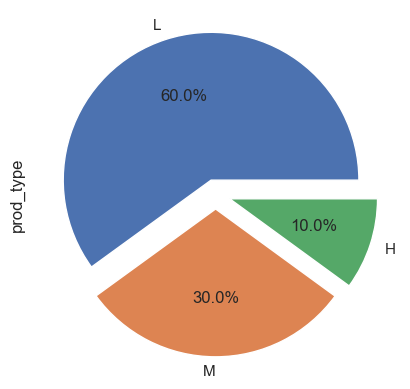

In [11]:
x=df['prod_type'].value_counts().plot.pie(explode=[0.1, 0.1,0.1],autopct='%1.1f%%')

In [12]:
# Binary Target Variable - Failure / No Failure
df.target.value_counts()

0    9661
1     339
Name: target, dtype: int64

In [13]:
df.target.value_counts() / len(df)*100

0    96.61
1     3.39
Name: target, dtype: float64

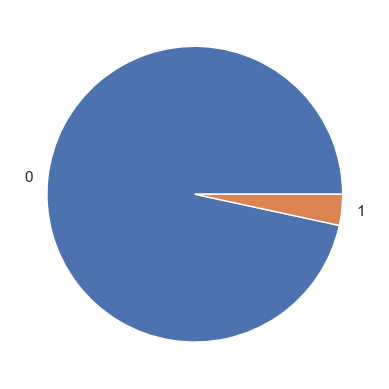

In [14]:
plt.pie(df.target.value_counts(), labels = df.target.unique())
plt.show()

In [15]:
# Failure Types Categories and Counts
df.failure_type.value_counts()

No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: failure_type, dtype: int64

In [16]:
# Investigating the difference between No Failure labeled sample number in Target and in Type
failure_df = df[['target','failure_type']][df['target'] == 0]
failure_df.value_counts()

target  failure_type   
0       No Failure         9643
        Random Failures      18
dtype: int64

In [17]:
failure_df_type = df[['target','failure_type']][df['failure_type'] == 'No Failure']
failure_df_type.value_counts()

target  failure_type
0       No Failure      9643
1       No Failure         9
dtype: int64

In [18]:
# Correcting Data Inconsistencies
df = df.drop(df[((df.failure_type == 'Random Failures') & (df.target == 0)) | ((df.target == 1) & (df.failure_type == 'No Failure'))].index)

In [19]:
df.shape

(9973, 10)

In [20]:
df.describe()

,uid,air_temp,process_temp,rot_speed,torque,tool_wear,target
count,9973.000000,9973.000000,9973.000000,9973.000000,9973.000000,9973.000000,9973.000000
mean,5000.770881,300.003259,310.004031,1538.893212,39.978993,107.921087,0.033089
std,2888.466894,2.000548,1.483692,179.412171,9.966805,63.649152,0.178879
min,1.000000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2499.000000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,4998.000000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7504.000000,301.500000,311.100000,1612.000000,46.700000,162.000000,0.000000
max,10000.000000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [21]:
# Contingency table of proportions for categorical variables

# Product Type and Target (Failure)
contingency_target_type = pd.crosstab(df.prod_type, df.target)
contingency_target_type / len(df) * 100

target,0,1
prod_type,,
H,9.806477,0.200541
L,57.685752,2.316254
M,29.198837,0.792139


In [22]:
# Applying extra time to tool wear according to the rule H/M/L = 5/3/2 added minutes added in the process
df.tool_wear = df.apply(lambda row: row['tool_wear'] + 5 if row['prod_type'] == 'H' else row['tool_wear'] + 3 if row['prod_type'] == 'M' else row['tool_wear'] + 2, axis = 1)

In [ ]:
sns.pairplot(df, hue='target', palette='husl')

In [ ]:
plt.figure(figsize=(8, 8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
fig, axes = plt.subplots(1,3, figsize=[15,5])
axes.flatten()
j=0
colors = ['#E1728F', '#409E7D'] 
for i in ['L', 'M', 'H']:
    df_product_type = df[df['prod_type'] == i]
    axes[j].pie(df_product_type['target'].value_counts(), labels=['Failure', 'Not failure'],
                autopct='%1.2f%%', wedgeprops={'edgecolor': 'black'}, shadow=True, startangle=25,
                colors=colors)
    axes[j].set_title('% of failure for ' + i + ' products')
    j+=1

In [ ]:
fig, ax = plt.subplots(1,2, figsize=[22,8])
plt.title('Rot. Speed vs Torque wrt Failure Type')
sns.scatterplot(data=df, x='rot_speed', y='torque', hue='failure_type', palette=['#E9C0CB', '#39A692', '#976EBD', '#ACBF5C', '#DF8B4E'], ax=ax[0])
sns.scatterplot(data=df[df['target'] == 1], x='rot_speed', y='torque', hue='failure_type', palette=['#39A692', '#976EBD', '#ACBF5C', '#DF8B4E'], ax=ax[1])

ax[0].set_title('Including class no failure')
ax[1].set_title('Excluding class no failure')

In [ ]:
print('----- SKEWNESS ------------')
fig, axes = plt.subplots(2, 5, figsize=[25,10])
j = 0
colors = ['#E1728F', '#409E7D']

for i in ['air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear']:
    sns.histplot(data=df, x=i, kde=True, ax=axes[0,j], hue='target', palette=colors)
    sns.boxplot(data=df, x=i, ax=axes[1,j], palette=['#976EBD'])
    j+=1
    print('{} skewness = {}'.format(i, round(df[i].skew(), 2)))
print('---------------------------')

In [ ]:
df

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

label_encoder.fit(df['prod_type'])
df['prod_type'] = label_encoder.transform(df['prod_type'])

label_encoder.fit(df['target'])
df['target'] = label_encoder.transform(df['target'])

In [ ]:
df

In [ ]:
df["failure_type"] = df["failure_type"].replace("No Failure", 0)
df["failure_type"] = df["failure_type"].replace("Tool Wear Failure", 1)
df["failure_type"] = df["failure_type"].replace("Heat Dissipation Failure", 2)
df["failure_type"] = df["failure_type"].replace("Power Failure", 3)
df["failure_type"] = df["failure_type"].replace("Overstrain Failure", 4)
df["failure_type"] = df["failure_type"].replace("Random Failures", 5)

In [ ]:
data = df.drop(["uid",'prod_id','failure_type'],axis=1)

In [ ]:
data

In [ ]:
x=data.drop(['target'],axis=1)
y=data['target']

print(x.shape,y.shape)

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote=SMOTE()
x,y=smote.fit_resample(x,y)

In [ ]:
print(y.value_counts())

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train   = scaler.fit_transform(X_train)     # Fit and transform the training & test set 
X_test    = scaler.fit_transform(X_test)  

In [ ]:
def evaluate(model):
    model.fit(X_train,y_train)
    accuracy=model.score(X_test,y_test)
    
    print('model name ',model)
    print('accuracy ',accuracy)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

lr=LogisticRegression()
svm=SVC()
dt=DecisionTreeClassifier(max_depth=6)
rf=RandomForestClassifier(max_samples=0.9)
knn=KNeighborsClassifier(n_neighbors=5)

models=[lr,svm,dt,rf,knn]

for model in models:
    evaluate(model)

In [ ]:
from sklearn.ensemble import StackingClassifier

In [ ]:
base_models=[('RF',RandomForestClassifier(max_samples=0.9)),
             ('knn',KNeighborsClassifier(n_neighbors=5))]
meta_model = SVC()
stacking_model = StackingClassifier(estimators=base_models, 
                                    final_estimator=meta_model, 
                                    passthrough=True, 
                                    cv=3)

In [ ]:
stacking_model.fit(X_train, y_train)
stacking_model.score(X_test,y_test)

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = stacking_model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot = True, fmt='g')

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

In [ ]:
!pip install xgboost
from xgboost import XGBClassifier

In [ ]:
xgb_params = {
    'booster': ['gbtree', 'dart'],
    'verbosity': [0],
    'eta': np.arange(0.1, 0.2, 0.05),
    'gamma': np.arange(0, 101),
    'max_depth': np.arange(3, 11),
    'tree_method': ['auto', 'approx', 'hist', 'exact'],
    'objective': ['binary:hinge'],
    'eval_metric': ['error', 'auc', 'aucpr']
}
randomized_search_xgb = RandomizedSearchCV(XGBClassifier(), xgb_params, n_iter=10, cv=5, scoring='accuracy')
randomized_search_xgb.fit(X_train, y_train)
randomized_search_xgb.best_params_

In [ ]:
clf_xgb = XGBClassifier(booster='gbtree', verbosity=0, eta=0.15, gamma=11, max_depth=8, tree_method='exact', objective='binary:hinge', eval_metric='error')

In [ ]:
cross_val_xgb = cross_val_score(clf_xgb, X_test, y_test, cv=5)
print(f'Mean: {(cross_val_xgb * 100).mean()}')
print(f'Values: {(cross_val_xgb * 100)}')

In [ ]:
clf_xgb.fit(X_train, y_train)
predict = clf_xgb.predict(X_test)
acc_xgb = clf_xgb.score(X_test, y_test)
print(classification_report(y_test, predict))
print(f'XGBoost acc = {(acc_xgb * 100):.2f}')

# Prediction

In [ ]:
stacking_model.fit(X_train, y_train)

In [ ]:
pred_train = stacking_model.predict(X_train)
(pred_train == y_train).mean()

In [ ]:
pred_test = stacking_model.predict(X_test)

In [ ]:
(pred_test == y_test).mean()

In [ ]:
temp_df = pd.DataFrame([list(y_test), list(pred_test)]).T
temp_df.columns=['y_test','pred_test']
temp_df2 = temp_df[temp_df['y_test'] == 1]
temp_df2

In [ ]:
np.mean(temp_df2['y_test'] == temp_df2['pred_test'])

In [ ]:
temp_df2.sample(25)